# Stage 5 — Prescriptive Analytics: *What should management do?*
Prescriptive analytics builds upon the findings of the descriptive, diagnostic and predictive analyses to recommend practical actions that improve the University's furniture reuse programme. Rather than identifying what has happened or predicting future outcomes, prescriptive analytics focuses on determining **what actions should be taken** to maximise procurement savings, increase furniture reuse and reduce disposal costs.

The recommendations presented in this chapter are derived directly from the analytical evidence generated in the previous stages and are intended to support decision-making for the University's circular economy strategy.




In [16]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

reuse = pd.read_csv("cleaned_reuse.csv")
disposal = pd.read_csv("cleaned_disposal.csv")
fc = pd.read_csv("scenario_forecast.csv")

total_sav = reuse["total_cost"].sum()
camp = reuse.groupby("campus")["total_cost"].sum()
item_sav = (reuse.assign(item=reuse["item_type"].str.strip().str.title())
            .groupby("item")["total_cost"].sum()
            .sort_values(ascending=False))
cum = item_sav.cumsum() / item_sav.sum() * 100
pareto_items = list(item_sav.index[: (cum <= 80).sum() + 1])
disp_val = disposal["total_value"].sum()
disp_top = (disposal.assign(item=disposal["item_type"].str.strip().str.title())
            .groupby("item")["total_value"].sum()
            .sort_values(ascending=False))
cen = fc[fc["scenario"].str.startswith("Central")]["annual_savings"].sum()
opt = fc[fc["scenario"].str.startswith("Optimistic")]["annual_savings"].sum()

## Recommendation 1 — Prioritise the Pareto item types
This recommendation evaluates whether procurement savings are concentrated within a relatively small number of furniture types. Identifying these items enables the University to prioritise resources towards furniture categories that generate the greatest financial return.



In [17]:
print(f"""FINDING       : {len(pareto_items)} item types
                ({', '.join(pareto_items)})
                generate 80% of all £{total_sav:,.0f} savings.
IMPLICATION   : Reuse effort is not equally valuable across items.
INTERVENTION  : Mandatory reuse-first check for these types before any
                new purchase order; priority storage + fast-track listing.
EXPECTED IMPACT: Protects ~80% of the £{cen:,.0f} five-year central-
                scenario savings.""")

FINDING       : 6 item types
                (Desk, Chair, Operator Chair, Sofa, Pedestal, Table)
                generate 80% of all £230,377 savings.
IMPLICATION   : Reuse effort is not equally valuable across items.
INTERVENTION  : Mandatory reuse-first check for these types before any
                new purchase order; priority storage + fast-track listing.
EXPECTED IMPACT: Protects ~80% of the £372,258 five-year central-
                scenario savings.


## Result
Six furniture types (Desk, Chair, Operator Chair, Sofa, Pedestal and Table) generated approximately **80% of the total procurement savings (£230,377).

## Analysis
The Pareto analysis demonstrates that procurement savings are highly concentrated among a relatively small number of furniture types. Only six item categories account for approximately **80% of the University's total procurement savings**, confirming the Pareto principle (80/20 rule).

This finding indicates that procurement savings are not distributed evenly across all furniture types. Instead, a limited number of high-value items generate the majority of financial benefits. Consequently, operational resources should be prioritised towards identifying, recovering and redistributing these furniture types before considering lower-value items.

Prioritising these six furniture categories is expected to maximise procurement savings while requiring comparatively fewer operational resources, thereby improving the overall efficiency of the reuse programme.



## Recommendation 2 — Transfer high-performing campus practice
This recommendation evaluates whether differences in procurement savings across campuses indicate opportunities to transfer successful operational practices between locations.




In [18]:
print(f"""FINDING       : Greenwich £{camp.get('Greenwich',0):,.0f} vs
                Avery Hill £{camp.get('Avery Hill',0):,.0f} and
                Medway £{camp.get('Medway',0):,.0f}; the disposal cross-tab
                shows Avery Hill/Medway dominate table & seating disposal.
IMPLICATION   : The gap is operational, not structural.
INTERVENTION  : Replicate Greenwich's cataloguing frequency, porter
                coordination and response process; named coordinator
                per campus.
EXPECTED IMPACT: Optimistic scenario (+10%/yr) projects £{opt:,.0f}
                cumulative vs £{cen:,.0f} status quo.""")

FINDING       : Greenwich £160,668 vs
                Avery Hill £60,921 and
                Medway £8,788; the disposal cross-tab
                shows Avery Hill/Medway dominate table & seating disposal.
IMPLICATION   : The gap is operational, not structural.
INTERVENTION  : Replicate Greenwich's cataloguing frequency, porter
                coordination and response process; named coordinator
                per campus.
EXPECTED IMPACT: Optimistic scenario (+10%/yr) projects £499,988
                cumulative vs £372,258 status quo.


## Results
Greenwich Campus generated substantially higher procurement savings (**£160,668**) than Avery Hill (**£60,921**) and Medway (**£8,788**). 

## Analysis

This suggests that Greenwich has developed more effective reuse processes, higher participation rates or stronger operational coordination.

When considered alongside the disposal cross-tabulation from the diagnostic analysis, Avery Hill and Medway exhibit greater disposal activity for seating and table furniture, indicating opportunities for operational improvement.

Rather than developing entirely new processes, the University could improve overall programme performance by adopting successful practices already implemented at Greenwich. Standardising furniture collection, redistribution procedures and inventory management across campuses would likely increase procurement savings while reducing disposal.


## Recommendation 3 — Digitise and mandate disposal recording
This recommendation assesses the completeness of disposal records and identifies opportunities to improve decision-making through better data quality.




In [22]:
print(f"""FINDING       : Recorded disposals total £{disp_val:,.0f} across
                only 61 observations in ~5 years — confirmed as a
                fraction of actual disposal.
IMPLICATION   : The University cannot manage what it cannot see.
INTERVENTION  : Digital disposal register — mandatory photo + item type +
                quantity before any skip disposal, integrated with the
                reuse register.
EXPECTED IMPACT: ILLUSTRATIVE ONLY — if recorded = 25% of true disposal,
                implied loss ≈ £{disp_val*4/5:,.0f}/year. Complete
                recording replaces this illustration with evidence.""")

FINDING       : Recorded disposals total £45,418 across
                only 61 observations in ~5 years — confirmed as a
                fraction of actual disposal.
IMPLICATION   : The University cannot manage what it cannot see.
INTERVENTION  : Digital disposal register — mandatory photo + item type +
                quantity before any skip disposal, integrated with the
                reuse register.
EXPECTED IMPACT: ILLUSTRATIVE ONLY — if recorded = 25% of true disposal,
                implied loss ≈ £36,334/year. Complete
                recording replaces this illustration with evidence.


## Results

- Recorded disposal value: **£45,418**
- Recorded observations: **61** over approximately five years

## Analysis

The recorded disposal dataset contains only **61 disposal observations**, representing approximately **£45,418** in recorded disposal value over a five-year period.

Given the size of the University's estate and furniture inventory, this relatively small number of recorded disposals suggests that disposal activities are not being consistently documented. Consequently, management may underestimate the true financial and environmental costs associated with furniture disposal.

Implementing a mandatory digital disposal recording system would improve data quality, increase transparency and provide a more reliable evidence base for future procurement and sustainability decisions. Enhanced disposal data would also strengthen predictive modelling and performance monitoring.



## Recommendation 4 — Operator-chair recovery pathway
This recommendation investigates whether targeted intervention for high-loss furniture types could reduce disposal costs and increase reuse performance.


In [23]:
top_item, top_val = disp_top.index[0], disp_top.iloc[0]
print(f"""FINDING       : '{top_item}' = £{top_val:,.0f} of recorded disposal
                value (single largest loss) while also a top-3 reuse earner.
IMPLICATION   : Coverage gap, not capability gap.
INTERVENTION  : 48-hour fast-track: porters flag before skip disposal,
                condition-check vs SOP, list on register.
EXPECTED IMPACT: Recovering half would have added ~£{top_val/2:,.0f}
                of procurement avoidance.""")

FINDING       : 'Operator Chair' = £19,474 of recorded disposal
                value (single largest loss) while also a top-3 reuse earner.
IMPLICATION   : Coverage gap, not capability gap.
INTERVENTION  : 48-hour fast-track: porters flag before skip disposal,
                condition-check vs SOP, list on register.
EXPECTED IMPACT: Recovering half would have added ~£9,737
                of procurement avoidance.


Operator Chairs represent the largest recorded disposal loss, accounting for **£19,474** of disposal value. Previous analyses also identified operator chairs as one of the University's highest-value reuse items, indicating that these items are both highly valuable and frequently discarded.

This finding suggests that the primary challenge is not the value of the furniture itself but the operational process used to recover and redistribute it.

Developing a dedicated recovery pathway for operator chairs—including inspection, refurbishment where necessary and redistribution across campuses—would likely reduce disposal costs while increasing procurement savings and environmental benefits.



## Interactive decision-support dashboard (Plotly)

An interactive dashboard was developed to integrate the outputs from the descriptive, diagnostic and predictive analyses into a single decision-support interface. The dashboard enables facilities managers to monitor procurement savings, compare campus performance, identify disposal hotspots and evaluate trends over time.

Four panels: campus savings, reuse-vs-disposal by category, savings trend,
and the five-year scenario projections. Exports to `dashboard.html`.

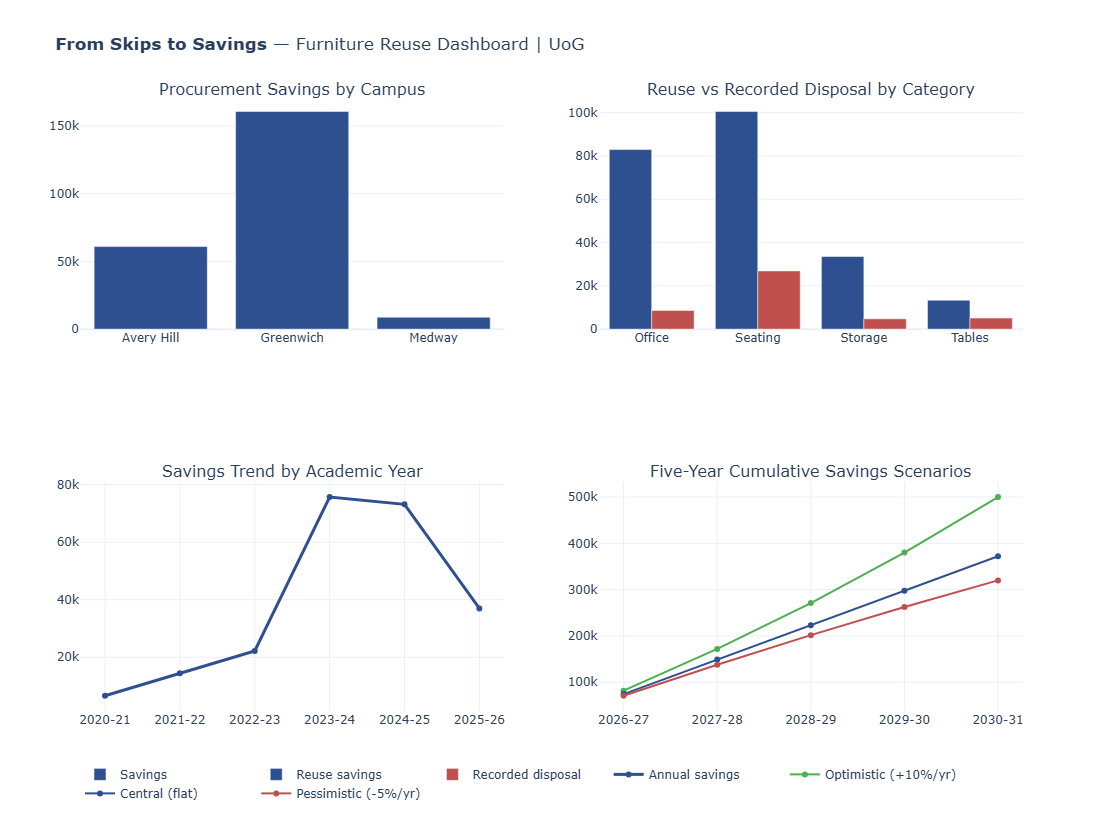

In [24]:
camp_r = reuse.groupby("campus")["total_cost"].sum()
cat_r = reuse.groupby("category")["total_cost"].sum()
cat_d = disposal.groupby("category")["total_value"].sum()
yr = (reuse[reuse["academic_year"] != "Unknown"]
      .groupby("academic_year")["total_cost"].sum())

fig = make_subplots(rows=2, cols=2, subplot_titles=(
    "Procurement Savings by Campus",
    "Reuse vs Recorded Disposal by Category",
    "Savings Trend by Academic Year",
    "Five-Year Cumulative Savings Scenarios"))

fig.add_trace(go.Bar(x=camp_r.index, y=camp_r.values,
                     marker_color="#2E5090", name="Savings"), row=1, col=1)
fig.add_trace(go.Bar(x=cat_r.index, y=cat_r.values, name="Reuse savings",
                     marker_color="#2E5090"), row=1, col=2)
fig.add_trace(go.Bar(x=cat_d.index, y=cat_d.values,
                     name="Recorded disposal",
                     marker_color="#C0504D"), row=1, col=2)
fig.add_trace(go.Scatter(x=yr.index, y=yr.values, mode="lines+markers",
                         name="Annual savings",
                         line=dict(color="#2E5090", width=3)), row=2, col=1)
colors = {"Optimistic (+10%/yr)": "#4CAF50", "Central (flat)": "#2E5090",
          "Pessimistic (-5%/yr)": "#C0504D"}
for s, c in colors.items():
    d = fc[fc["scenario"] == s]
    fig.add_trace(go.Scatter(x=d["year"], y=d["cumulative_savings"],
                             mode="lines+markers", name=s,
                             line=dict(color=c)), row=2, col=2)

fig.update_layout(
    title="<b>From Skips to Savings</b> — Furniture Reuse Dashboard | UoG",
    height=820, barmode="group", template="plotly_white",
    legend=dict(orientation="h", y=-0.08))
fig.write_html("dashboard.html", include_plotlyjs="cdn")
fig.show()

## Dashboard Components

The dashboard integrates four complementary visualisations:

- **Campus Procurement Savings:** compares procurement savings generated across Avery Hill, Greenwich and Medway campuses.
- **Reuse versus Recorded Disposal by Furniture Category:** compares the financial value of furniture successfully reused against items recorded as disposed of for each furniture category.
- **Procurement Savings Trend:** illustrates changes in procurement savings over successive academic years, allowing managers to monitor programme performance over time.
- **Five-Year Scenario Forecast:** presents optimistic, central and pessimistic projections of future procurement savings based on different levels of reuse activity.

The completed dashboard is exported as **dashboard.html**, allowing it to be opened in any modern web browser without requiring Python or Jupyter Notebook.




### Results

The dashboard presents four complementary visualisations summarising the University's furniture reuse programme.

The **Procurement Savings by Campus** chart shows that **Greenwich Campus** achieved the highest procurement savings (approximately **£160,000**), followed by **Avery Hill** (approximately **£61,000**) and **Medway** (approximately **£9,000**).

The **Reuse versus Recorded Disposal by Category** chart indicates that reuse savings exceed recorded disposal values across all four furniture categories. **Seating** generated the highest reuse savings (approximately **£100,000**), followed by **Office furniture** (approximately **£82,000**), while **Storage** and **Tables** contributed lower procurement savings. Recorded disposal values were highest for **Seating** (approximately **£27,000**) and lowest for **Storage** and **Tables**.

The **Savings Trend by Academic Year** demonstrates that procurement savings increased from approximately **£7,000** in **2020–21** to a peak of around **£75,000** in **2023–24**. Savings remained high during **2024–25** (approximately **£73,000**) before declining to approximately **£37,000** in **2025–26**.

The **Five-Year Cumulative Savings Scenarios** illustrate projected cumulative procurement savings under three assumptions. The **Optimistic Scenario (+10% annual growth)** reaches approximately **£500,000** by **2030–31**, the **Central Scenario** reaches approximately **£370,000**, while the **Pessimistic Scenario (-5% annual decline)** reaches approximately **£320,000**.

### Analysis

The dashboard demonstrates considerable variation in procurement savings between campuses. Greenwich contributes the largest proportion of procurement savings, generating more than twice the savings achieved at Avery Hill and substantially exceeding Medway. This finding indicates that furniture reuse activity is considerably more effective at Greenwich, highlighting opportunities to transfer successful operational practices to the other campuses.

The comparison between reuse savings and recorded disposal shows that the University's furniture reuse programme consistently generates greater financial value than the value associated with disposal across every furniture category. Seating represents the most valuable category, producing approximately **£100,000** in procurement savings. However, it also records the highest disposal value, indicating that seating furniture remains the category with the greatest potential for improving reuse performance and reducing unnecessary disposal.

The historical trend demonstrates significant growth in procurement savings between **2020–21** and **2023–24**, reflecting substantial improvement in programme performance over time. Although savings decreased during **2025–26**, they remained considerably higher than those achieved during the initial years of the programme, indicating that the furniture reuse initiative continues to deliver substantial financial benefits.

The scenario analysis further demonstrates the long-term financial impact of reuse activities. Under the optimistic scenario, cumulative procurement savings increase to approximately **£500,000**, exceeding the pessimistic scenario by around **£180,000** over five years. This difference highlights the financial benefits of maintaining or expanding current reuse practices and demonstrates that relatively small annual improvements can produce substantial long-term procurement savings.

Overall, the dashboard confirms that the furniture reuse programme delivers significant procurement savings across the University while identifying clear opportunities for further improvement. Greenwich represents the strongest-performing campus, seating is the highest-value furniture category for both reuse and disposal, procurement savings have increased substantially over time, and future financial outcomes are strongly influenced by the University's ability to sustain and enhance furniture reuse activities.